# McNemar: paired significance for “fault near the top” (Acc@*K*)

For each **bug** and each method, we use the **best** `autofl_rank`. Define **success** = fault is localized **near the top** ⇔ `best_rank ≤ K` (Acc@*K* as a **binary** outcome).

For the **same** bugs, we compare a **target** (e.g. `reportfl`) to a **baseline** row-by-row. The paired 2×2 layout is:

|  | baseline not @*K* | baseline @*K* |
|--|------------------|--------------|
| **target not @*K*** | n00 (both miss) | n01 (only baseline) |
| **target @*K*** | n10 (only target) | n11 (both hit) |

**McNemar’s test** uses only **discordant** pairs: *n*10 = **only target** hits top-*K*, *n*01 = **only baseline** hits top-*K*. Under H0, those two are equally likely (p = 0.5) among discordant cases.

We report the **two-sided** exact *p*-value with **`scipy.stats.binomtest(n10, n10+n01, 0.5, alternative=\"two-sided\")`**, which is the standard **exact McNemar** for the 2×2 case (no `statsmodels` required). Optional **one-sided** tests are available if you preregister a direction (target more often in top-*K* than baseline on discordant pairs).

This is appropriate for “**which method is more often in the top-*K* set** on the same faults,” not for the full **continuous** rank scale (for that, see `paired_wilcoxon_ranks.ipynb`).


In [1]:
import json
from collections.abc import Iterable
from typing import TypedDict

from scipy.stats import binomtest


class McNemarResult(TypedDict):
    n10: int  # only target @K
    n01: int  # only baseline @K
    n00: int
    n11: int
    n_discordant: int
    p_two_sided: float
    p_one_sided_n10: float  # binom(n10, d, 0.5) greater: target-wins on discordant


def extract_best_ranks(data: dict) -> dict[str, float]:
    bug_ranks: dict[str, float] = {}
    for bug, methods in data.get("buggy_methods", {}).items():
        ranks: list[float] = []
        for m in methods.values():
            if not isinstance(m, dict):
                continue
            r = m.get("autofl_rank")
            if r is not None:
                ranks.append(float(r))
        if ranks:
            bug_ranks[bug] = min(ranks)
        else:
            bug_ranks[bug] = None
    return bug_ranks


def get_ranks(exp_name: str, gpt_version: str, repetition: int) -> dict[str, float]:
    score_path_json = f"../combined_fl_results/{exp_name}/{gpt_version}_R{repetition}_full_light.json"
    #print (score_path_json)
    with open(score_path_json, "r", encoding="utf-8") as f:
        data: dict = json.load(f)
    return extract_best_ranks(data)


def success_at_k(rank: float, k: int) -> bool:
    return float(rank) <= float(k)


def mcnemar_topk(
    r_target: dict[str, float],
    r_baseline: dict[str, float],
    k: int,
) -> McNemarResult:
    """McNemar (exact) on Acc@K success for the same set of bugs."""
    common = sorted(set(r_target) & set(r_baseline))
    #only_target = sorted(set(r_target) - set(r_baseline))
    #only_baseline = sorted(set(r_baseline) - set(r_target))
    n00 = n01 = n10 = n11 = 0
    for bug in common:
        t, b = r_target[bug], r_baseline[bug]
        if t is None and b is None:
            st, sb = False, False
        elif t is None:
            sb = success_at_k(b, k)
            st = False
        elif b is None:
            sb = False
            st = success_at_k(t, k)
        else:
            st, sb = success_at_k(t, k), success_at_k(b, k)
            
        if not st and not sb:
            n00 += 1
        elif not st and sb:
            n01 += 1
        elif st and not sb:
            n10 += 1
        else:
            n11 += 1
            
    # # Unpaired keys: impute the missing method as "not @K" (no rank → not success), so
    # # the other method's @K result maps to n00 (both miss) or n10 / n01 (single hit).
    # for bug in only_target:
    #     t = r_target[bug]
    #     if t is None:
    #         n00 += 1
    #     else:
    #         st = success_at_k(t, k)
    #         if st:
    #             n10 += 1
    #         else:
    #             n00 += 1

    # for bug in only_baseline:
    #     b = r_baseline[bug]
    #     if b is None:
    #         n00 += 1
    #     else:
    #         sb = success_at_k(b, k)
    #         if sb:
    #             n01 += 1
    #         else:
    #             n00 += 1
    
    #print ("N", len(only_target), len(only_baseline), len(common))
    d = n10 + n01
    if d == 0:
        p2 = 1.0
        p1g = 1.0
    else:
        p2 = float(binomtest(n10, d, 0.5, alternative="two-sided").pvalue)
        p1g = float(binomtest(n10, d, 0.5, alternative="greater").pvalue)
        
    return {
        "n10": n10,
        "n01": n01,
        "n00": n00,
        "n11": n11,
        "n_discordant": d,
        "p_two_sided": p2,
        "p_one_sided_n10": p1g,
    }


def _fmt_p(p: float) -> str:
    if p != p:
        return "nan"
    if p < 1e-12:
        return "<1e-12"
    if p < 0.001:
        return f"{p:.2e}"
    return f"{p:.3f}"


def mcnemar_table_baselines(
    target_exp: str,
    gpt_version: str = "gpt-3.5-turbo-0125",
    k_list: Iterable[int] = (1, 3, 5, 10),
    repetitions: tuple[int, ...] = (1, 5),
    one_sided_note: bool = True,
) -> None:
    """Print McNemar p-values for target vs {current, autofl_onlyft, autofl} at each K and R."""
    for rep in repetitions:
        current = get_ranks("current", gpt_version, rep)
        onlyft = get_ranks("autofl_onlyft", gpt_version, rep)
        afl = get_ranks("autofl", gpt_version, rep)
        target = get_ranks(target_exp, gpt_version, rep)
        cnt_better = 0
        for k in k_list:
            print(f"% --- K={k}, R{rep} --- {target_exp} vs baselines, {gpt_version}")
            for name, bl in (
                ("current", current),
                ("autofl_onlyft", onlyft),
                ("autofl", afl),
            ):
                r = mcnemar_topk(target, bl, k)
                if r['n10'] > r['n01'] and name == 'current':
                    cnt_better += 1
                s = (
                    f"& K={k} & {name} & n10={r['n10']} & n01={r['n01']} & "
                    f"d={r['n_discordant']} & p2={_fmt_p(r['p_two_sided'])}"
                )
                if one_sided_note:
                    s += (
                        f" & p1_greater={_fmt_p(r['p_one_sided_n10'])} "
                        f"(one-sided, H1: n10>n01 side of table)"
                    )
                s += f"  % (n00={r['n00']}, n11={r['n11']})"
                print(s)
            print()
        print ("winning freq", target_exp, f"R{rep}", len(k_list), cnt_better)

In [2]:
# gpt-3.5: 30d / 60d / 90d reportfl variants, Acc@1,3,5,10, R1 and R5
for exp, label in (
    ("reportfl", "30d"),
    ("reportfl_60days", "60d"),
    ("reportfl_90days", "90d"),
):
    print(f"% ========== {label} {exp} — gpt-3.5-turbo-0125 ==========")
    mcnemar_table_baselines(exp, gpt_version="gpt-3.5-turbo-0125", k_list=(1, 2, 3, 4, 5))


% ========== 30d reportfl — gpt-3.5-turbo-0125 ==========
% --- K=1, R1 --- reportfl vs baselines, gpt-3.5-turbo-0125
& K=1 & current & n10=33 & n01=29 & d=62 & p2=0.704 & p1_greater=0.352 (one-sided, H1: n10>n01 side of table)  % (n00=163, n11=77)
& K=1 & autofl_onlyft & n10=40 & n01=24 & d=64 & p2=0.060 & p1_greater=0.030 (one-sided, H1: n10>n01 side of table)  % (n00=168, n11=70)
& K=1 & autofl & n10=26 & n01=40 & d=66 & p2=0.109 & p1_greater=0.968 (one-sided, H1: n10>n01 side of table)  % (n00=152, n11=84)

% --- K=2, R1 --- reportfl vs baselines, gpt-3.5-turbo-0125
& K=2 & current & n10=29 & n01=26 & d=55 & p2=0.788 & p1_greater=0.394 (one-sided, H1: n10>n01 side of table)  % (n00=153, n11=94)
& K=2 & autofl_onlyft & n10=40 & n01=24 & d=64 & p2=0.060 & p1_greater=0.030 (one-sided, H1: n10>n01 side of table)  % (n00=155, n11=83)
& K=2 & autofl & n10=24 & n01=52 & d=76 & p2=0.002 & p1_greater=1.000 (one-sided, H1: n10>n01 side of table)  % (n00=127, n11=99)

% --- K=3, R1 --- report

In [18]:
# gpt-4.1-mini
for exp, label in (
    ("reportfl", "30d"),
    ("reportfl_60days", "60d"),
    ("reportfl_90days", "90d"),
):
    print(f"% ========== {label} {exp} — gpt-4.1-mini-2025-04-14 ==========")
    mcnemar_table_baselines(
        exp, gpt_version="gpt-4.1-mini-2025-04-14", k_list=(1, 2, 3, 4, 5)
    )


% ========== 30d reportfl — gpt-4.1-mini-2025-04-14 ==========
% --- K=1, R1 --- reportfl vs baselines, gpt-4.1-mini-2025-04-14
& K=1 & current & n10=15 & n01=17 & d=32 & p2=0.860 & p1_greater=0.702 (one-sided, H1: n10>n01 side of table)  % (n00=108, n11=162)
& K=1 & autofl_onlyft & n10=56 & n01=18 & d=74 & p2=1.11e-05 & p1_greater=5.55e-06 (one-sided, H1: n10>n01 side of table)  % (n00=107, n11=121)
& K=1 & autofl & n10=65 & n01=18 & d=83 & p2=2.11e-07 & p1_greater=1.05e-07 (one-sided, H1: n10>n01 side of table)  % (n00=107, n11=112)

% --- K=2, R1 --- reportfl vs baselines, gpt-4.1-mini-2025-04-14
& K=2 & current & n10=17 & n01=14 & d=31 & p2=0.720 & p1_greater=0.360 (one-sided, H1: n10>n01 side of table)  % (n00=86, n11=185)
& K=2 & autofl_onlyft & n10=52 & n01=13 & d=65 & p2=1.17e-06 & p1_greater=5.84e-07 (one-sided, H1: n10>n01 side of table)  % (n00=87, n11=150)
& K=2 & autofl & n10=53 & n01=21 & d=74 & p2=2.56e-04 & p1_greater=1.28e-04 (one-sided, H1: n10>n01 side of table)  % (

In [ ]:
# McNemar LaTeX tables: Acc@K. vs \namecr: discordant n10/n01; vs \autoflonlyft / \autofl: two-sided p.
# Requires: booktabs, multirow. Define \namecr, \autoflonlyft, \autofl in the preamble.

def _fmt_p_latex_cell(p: float, alpha: float = 0.05) -> str:
    if p != p:
        return r"\text{nan}"
    if p < 0.001:
        s = r"< 0.001"
    else:
        s = f"{p:.3f}"
    if p < alpha:
        return r"\textbf{" + s + "}"
    return s


def _fmt_n10_n01_latex(n10: int, n01: int) -> str:
    if n10 > n01:
        return rf"\textbf{{{n10}}} / {n01}"
    if n01 > n10:
        return rf"{n10} / \textbf{{{n01}}}"
    return f"{n10} / {n01}"


def mcnemar_latex_table_string(
    k: int,
    alpha: float = 0.05,
) -> str:
    models = [
        ("gpt-3.5-turbo-0125", "GPT-3.5"),
        ("gpt-4.1-mini-2025-04-14", "GPT-4.1-mini"),
    ]
    experiments = [
        ("reportfl", "30d"),
        ("reportfl_60days", "60d"),
        ("reportfl_90days", "90d"),
    ]
    n_rows = len(experiments) * 2
    lines = [
        r"\begin{tabular}{lc|rrr}",
        r"\toprule",
        r"& & \multicolumn{3}{c}{\textbf{vs.}} \\",
        r"& \textbf{Configuration} & \textbf{\namecr} & \textbf{\autoflonlyft} & \textbf{\autofl} \\",
        r"\textbf{LLM} & \textbf{Days (M)} & ($n_{10}/n_{01}$) & p-value & p-value \\",
        r"\midrule",
    ]
    for mi, (model_id, model_name) in enumerate(models):
        first = True
        for rep in (1, 5):
            for exp_id, exp_label in experiments:
                r_target = get_ranks(exp_id, model_id, rep)
                vs_cr = mcnemar_topk(r_target, get_ranks("current", model_id, rep), k)
                vs_onlyft = mcnemar_topk(
                    r_target, get_ranks("autofl_onlyft", model_id, rep), k
                )
                vs_afl = mcnemar_topk(r_target, get_ranks("autofl", model_id, rep), k)
                pair = _fmt_n10_n01_latex(vs_cr["n10"], vs_cr["n01"])
                p_of = _fmt_p_latex_cell(vs_onlyft["p_two_sided"], alpha)
                p_afl = _fmt_p_latex_cell(vs_afl["p_two_sided"], alpha)
                conf = f"{exp_label} (M={rep})"
                if first:
                    llm = f"\\multirow{{{n_rows}}}{{*}}{{{model_name}}}"
                    first = False
                else:
                    llm = ""
                lines.append(f"{llm} & {conf} & {pair} & {p_of} & {p_afl} \\\\")
        if mi < len(models) - 1:
            lines.append(r"\midrule")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    return "\n".join(lines)


def print_mcnemar_latex_tables(
    k_list: tuple[int, ...] = (1, 2, 3, 4, 5),
    alpha: float = 0.05,
) -> None:
    for k in k_list:
        print(f"% ========== Acc@{k} McNemar (reportfl vs current / onlyft / autofl) ==========")
        print(mcnemar_latex_table_string(k, alpha=alpha))
        print()


print_mcnemar_latex_tables(k_list=(1, 2, 3, 4, 5))

## Rank Plot

../combined_fl_results/current/gpt-4.1-mini-2025-04-14_R1_full_light.json
../combined_fl_results/autofl_onlyft/gpt-4.1-mini-2025-04-14_R1_full_light.json
../combined_fl_results/autofl/gpt-4.1-mini-2025-04-14_R1_full_light.json
../combined_fl_results/reportfl/gpt-4.1-mini-2025-04-14_R1_full_light.json


/tmp/ipykernel_1736836/1554974671.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([list(current.values()), list(onlyft.values()), list(afl.values()), list(target.values())], labels=["current", "autofl_onlyft", "autofl", target_exp], showfliers=False, vert=False)


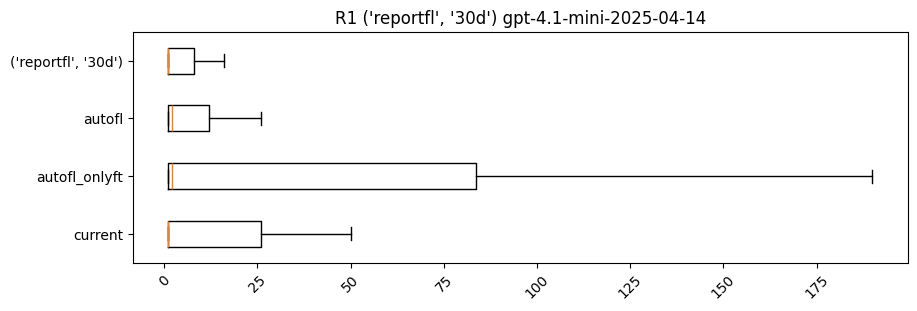

../combined_fl_results/current/gpt-4.1-mini-2025-04-14_R5_full_light.json
../combined_fl_results/autofl_onlyft/gpt-4.1-mini-2025-04-14_R5_full_light.json
../combined_fl_results/autofl/gpt-4.1-mini-2025-04-14_R5_full_light.json
../combined_fl_results/reportfl/gpt-4.1-mini-2025-04-14_R5_full_light.json


/tmp/ipykernel_1736836/1554974671.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([list(current.values()), list(onlyft.values()), list(afl.values()), list(target.values())], labels=["current", "autofl_onlyft", "autofl", target_exp], showfliers=False, vert=False)


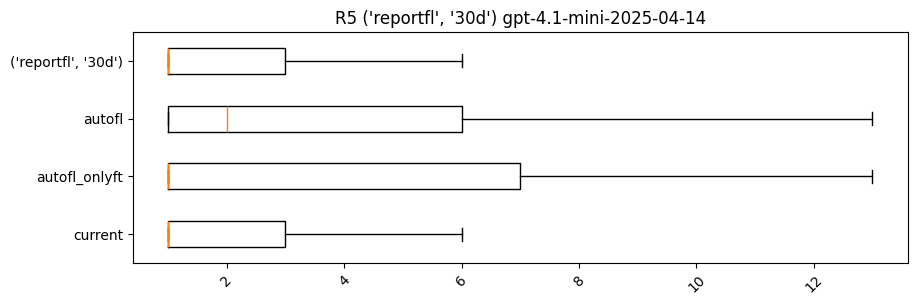

In [30]:
import matplotlib.pyplot as plt

gpt_version="gpt-4.1-mini-2025-04-14"
#gpt_version="gpt-3.5-turbo-0125"
target_exp = ("reportfl", "30d")
for rep in [1,5]:
    current = get_ranks("current", gpt_version, rep)
    onlyft = get_ranks("autofl_onlyft", gpt_version, rep)
    afl = get_ranks("autofl", gpt_version, rep)
    exp, days = target_exp
    if days != "30d":
        exp = f"{exp}_{days}ays" 
    target = get_ranks(exp, gpt_version, rep)
    
    plt.figure(figsize=(10, 3))
    plt.boxplot([list(current.values()), list(onlyft.values()), list(afl.values()), list(target.values())], labels=["current", "autofl_onlyft", "autofl", target_exp], showfliers=False, vert=False)
    plt.xticks(rotation=45)
    plt.title(f"R{rep} {target_exp} {gpt_version}")
    plt.show()

In [72]:
gpt_version="gpt-3.5-turbo-0125"
gpt_version="gpt-4.1-mini-2025-04-14"
afl = get_ranks("autofl", gpt_version, 1)
print (len(afl))
sum(list(map(success_at_k,  list[float](afl.values()), [1]*len(afl))))

../combined_fl_results/autofl/gpt-4.1-mini-2025-04-14_R1_full_light.json
289


130

In [73]:
gpt_version="gpt-3.5-turbo-0125"
gpt_version="gpt-4.1-mini-2025-04-14"
afl = get_ranks("reportfl", gpt_version, 1)
print (len(afl))
sum(list(map(success_at_k,  list[float](afl.values()), [1]*len(afl))))

../combined_fl_results/reportfl/gpt-4.1-mini-2025-04-14_R1_full_light.json
289


177

In [67]:
len(list[float](afl.values()))

289